## Boolean analysis

Here we are trying to apply Boolean Fourier Analysis to the sign structure. The main reference is:

- Ryan O'Donnel. [Analysis of Boolean Functions](http://www.cs.cmu.edu/~odonnell/papers/Analysis-of-Boolean-Functions-by-Ryan-ODonnell.pdf).

Caveat: our space is not a space of boolean functions defined on $\{0,1\}^n$, as we are working in the sector of zero magnetization (equal number of spins up and down). So, the set of parity functions that is used as a basis in BFA is *not* an orthonormal basis of the space of boolean functions defined in the sector of zero magnetization.

Possible workarounds:

- It is possible to consider the full eigenstate $\{0, 1\}^n \to \mathbb R$, not only the sign structure. Products are still form the orthonormal basis in this space.
- It is possible to consider the sign structure with zeroes: $\{0, 1\}^n \to \{-1, 0, 1\}$.
- Populate the space outside of the sector of zero magnetization with +1/-1 randomly instead of 0's.

In [1]:
import black
import jupyter_black

jupyter_black.load(
    lab=False,
    line_length=79,
    target_version=black.TargetVersion.PY39,
)

<IPython.core.display.Javascript object>

In [2]:
from pathlib import Path

FOURIER_BASIS_DIR = Path("fourier-bases")
FOURIER_BASIS_DIR.mkdir(exist_ok=True)

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import lattice_symmetries as ls
from tqdm import tqdm
from pathlib import Path
from typing import Literal
from dotmap import DotMap
from ipywidgets import interact, interact_manual
from hashlib import md5

from heisenberg_hamiltonians import (
    make_unpacked_configurations,
    HeisenbergJ1J2,
    SpinSystem,
)

from spin_lattices import (
    SpinLattice,
    ChainLattice,
    SquareLattice,
    KagomeLattice,
)

from scipy.stats import entropy

%matplotlib inline

In [4]:
def parity_of_1s(x: np.ndarray, n: int, show_progress=False):
    """
    Calculates the parities of number of 1's for all elements of x

    Params
    ------
    x : np.ndarray
        should have dtype == 'uint64'

    n : int
        number of bits (all elements of x should be less than 2 ** n)

    show_progress : bool
                    whether to show progress bar

    Returns
    -------
    parity : np.ndarray
             dtype == 'uint8'
    """

    parity = np.zeros_like(x, dtype="uint8")
    x = x.copy()
    for i in [lambda _: _, tqdm][show_progress](range(n)):
        parity ^= x & 1
        x >>= 1
    return parity


assert (
    np.isclose(
        parity_of_1s(np.array([[1, 2, 3], [4, 5, 6]], dtype="uint64"), 3),
        np.array([[1, 1, 0], [1, 0, 0]], dtype="uint64"),
    )
).all()

In [5]:
fb = ls.SpinBasis(
    ls.Group([]),
    number_spins=10,
    hamming_weight=None,
    spin_inversion=None,
)
fb.build()
fb.states.dtype

dtype('uint64')

In [28]:
SignalOption = Literal["sign", "value"]


class BooleanFourierAnalyser:
    def __init__(
        self,
        system: SpinSystem,
        use_symmetries=True,
        fourier_transform_matrix_cache=None,
    ):

        self.system = system

        number_spins = self.system.number_spins
        canonical_basis = self.system.canonical_basis

        if use_symmetries:
            self.fourier_basis = ls.SpinBasis(
                self.system.symmetry_group,
                number_spins=number_spins,
                hamming_weight=None,
                spin_inversion=None,
            )
        else:
            self.fourier_basis = ls.SpinBasis(
                ls.Group([]),
                number_spins=number_spins,
                hamming_weight=None,
                spin_inversion=None,
            )

        self.fourier_basis.build()

        fourier_basis_id = md5(
            f"{number_spins}{canonical_basis.hamming_weight}"
            f"{self.fourier_basis.states!r}".encode("utf8"),
            usedforsecurity=False,
        ).hexdigest()

        fourier_transform_matrix_path = FOURIER_BASIS_DIR / Path(
            f"fourier_transform_matrix-{fourier_basis_id}.feather"
        )

        self.fourier_transform_matrix: np.array = None
        # fourier_transform_matrix is a matrix, rows: states of a canonical basis
        # columns: subset masks, values: value of the parity function
        # defined by the subset mask on the state

        if fourier_transform_matrix_cache is not None:
            if (
                cached_basis := fourier_transform_matrix_cache.get(
                    fourier_basis_id
                )
            ) is not None:
                print("Found cached fourier basis, will use it")
                self.fourier_transform_matrix = cached_basis

        if self.fourier_transform_matrix is None:
            if fourier_transform_matrix_path.exists():
                print(
                    f"Fourier transform matrix found at {fourier_transform_matrix_path}"
                )
                fourier_transform_matrix_df = pd.read_feather(
                    fourier_transform_matrix_path
                ).set_index("index")
                if (
                    fourier_transform_matrix_df.index != canonical_basis.states
                ).any():
                    raise ValueError(
                        f"basis states in file {fourier_transform_matrix_path} do not coincide with "
                        f"self.system.canonical_basis"
                    )
                self.fourier_transform_matrix = (
                    fourier_transform_matrix_df.values.astype("int8")
                )

        if self.fourier_transform_matrix is None:
            print(
                "Fourier transform matrix not found, we have to calculate it. "
                "This can take some time, you can get a coffee."
            )
            self.fourier_transform_matrix = (
                self.make_fourier_transform_matrix()
            )

        if not fourier_transform_matrix_path.exists():
            print(f"Saving basis to file {fourier_transform_matrix_path}")
            pd.DataFrame(
                self.fourier_transform_matrix,
                index=self.system.canonical_basis.states.astype("uint64"),
                columns=[str(i) for i in self.fourier_basis.states],
            ).reset_index().to_feather(fourier_transform_matrix_path)

        if fourier_transform_matrix_cache is not None:
            fourier_transform_matrix_cache[
                fourier_basis_id
            ] = self.fourier_transform_matrix

        print("Finding system ground state")
        self.system.get_ground_state()

        self.spectre_df = DotMap(
            {
                signal: self.get_fourier_spectre_df(signal=signal)
                for signal in ["sign", "value"]
            }
        )

    def make_fourier_transform_matrix(self):
        masks = self.fourier_basis.states.reshape(1, -1)
        masked = self.system.canonical_basis.states.reshape(-1, 1) & masks
        parities = parity_of_1s(
            masked, self.system.number_spins, show_progress=True
        )
        return parities.astype("int8") * 2 - 1

    def fourier_decomposition(self, signal):
        return (
            self.fourier_transform_matrix.T
            @ signal
            / self.fourier_transform_matrix.shape[0]
        )

    def get_fourier_spectre_df(self, signal: SignalOption):
        signal_ = self.system.get_df_ground_state(canonical_basis=True)[
            "ground_state_coeff"
        ]
        if signal == "sign":
            signal_ = np.sign(signal_)

        return (
            pd.DataFrame(
                dict(
                    subset=list(
                        make_unpacked_configurations(
                            self.fourier_basis.states,
                            number_spins=self.system.number_spins,
                        )
                    ),
                    coeff=self.fourier_decomposition(signal_),
                )
            )
            .assign(abs_coeff=lambda x: np.abs(x["coeff"]))
            .sort_values("abs_coeff", ascending=False)
        )

    def visualize_spectre_support_barplot(
        self, signal: SignalOption, abs=False, elements=20, ax=None
    ):
        if ax is None:
            ax = plt.gca()
        return (
            self.spectre_df[signal]
            .iloc[:elements]
            .plot.bar(y="abs_coeff" if abs else "coeff", ax=ax)
        )

    def visualize_spectre_support_lattice(
        self, signal: SignalOption, k=0, ax=None
    ):
        if ax is None:
            ax = plt.gca()
        self.system.lat.plot(
            spins=self.spectre_df[signal]["subset"].iloc[k], ax=ax
        )
        ax.set_title(f"subset: {self.spectre_df[signal].index[k]}")

    def visualize_spectre_values_hist(
        self, signal: SignalOption, abs=False, bins=50, ax=None
    ):
        if ax is None:
            ax = plt.gca()
        return self.spectre_df[signal]["abs_coeff" if abs else "coeff"].hist(
            bins=bins, ax=ax
        )

    def spectre_entropy(self, signal: SignalOption):
        abs_coeff = self.spectre_df[signal]["abs_coeff"]
        return entropy(abs_coeff / abs_coeff.sum())

In [29]:
fourier_transform_matrix_cache = {}

In [30]:
analyzer = BooleanFourierAnalyser(
    system=HeisenbergJ1J2(
        SquareLattice(width=4, height=4),
        J1=1,
        J2=0,
        use_symmetries=True,
        spin_inversion=1,
    ),
    use_symmetries=True,
    fourier_transform_matrix_cache=fourier_transform_matrix_cache,
)

self.number_spins=16
Symmetry group contains 128 elements
Hilbert space dimension is 107
Fourier transform matrix not found, we have to calculate it. This can take some time, you can get a coffee.


100%|██████████| 16/16 [00:01<00:00, 13.88it/s]


Saving basis to file fourier-bases/fourier_transform_matrix-8ebd7d1fc04eb53805356b608299a4ef.feather
Finding system ground state
Using cached version of eigenvalues / eigenstates
Ground state energy is -44.9139328337


Okay, that's the Marshall's sign rule. Seems to be working.

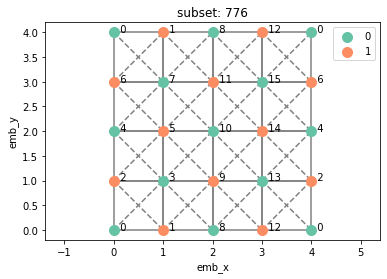

In [31]:
analyzer.visualize_spectre_support_lattice("sign")

<AxesSubplot: >

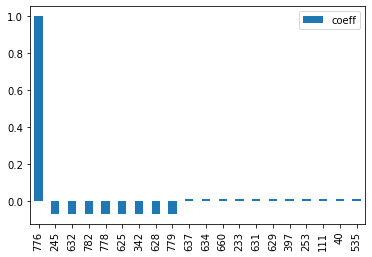

In [32]:
analyzer.visualize_spectre_support_barplot("sign")

<AxesSubplot: >

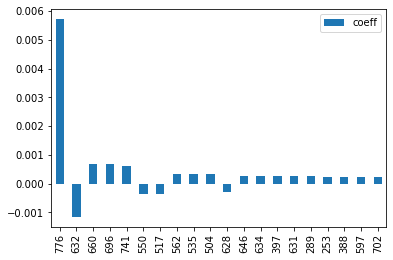

In [33]:
analyzer.visualize_spectre_support_barplot("value")

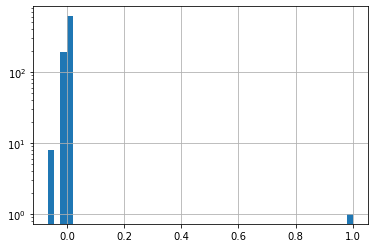

In [34]:
analyzer.visualize_spectre_values_hist("sign")
plt.yscale("log")

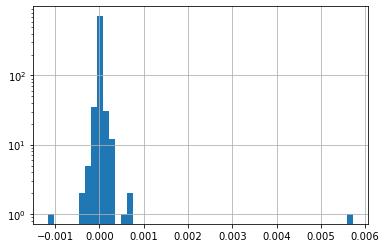

In [35]:
analyzer.visualize_spectre_values_hist("value")
plt.yscale("log")

In [36]:
analyzer.spectre_entropy("sign")

5.1028120281512335

In [37]:
analyzer.spectre_entropy("value")

4.101916547701223

Entropy seems to be wrong measure of "spreadness" of the function over the basis.

<AxesSubplot: >

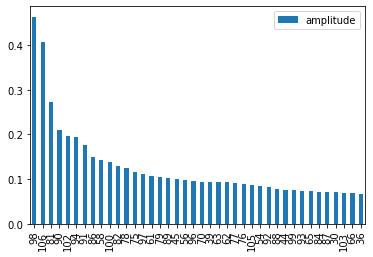

In [38]:
analyzer.system.get_df_ground_state().sort_values(
    "amplitude", ascending=False
).iloc[:40].plot.bar(y="amplitude")

<AxesSubplot: >

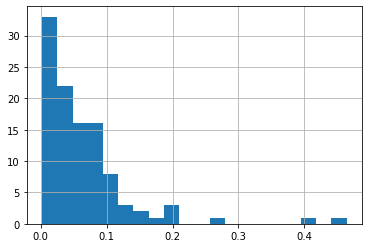

In [39]:
analyzer.system.get_df_ground_state()["amplitude"].hist(bins=20)

In [40]:
# analyzer_cache = {
#     J2: BooleanFourierAnalyser(
#         system=HeisenbergJ1J2(
#             SquareLattice(width=4, height=4),
#             J1=1,
#             J2=J2,
#             use_symmetries=True,
#             spin_inversion=1,
#         ),
#         fourier_basis_cache=fourier_basis_cache,
#     )
#     for J2 in tqdm(np.linspace(0, 1, 50))
# }

In [42]:
# from IPython.display import clear_output, display
# from time import sleep

In [43]:
# fig, ax = plt.subplots()
# # created a figure and axes to draw on them

# for J2, analyzer in sorted(analyzer_cache.items()):
#     clear_output(wait=True)
#     plt.gca().clear()
#     analyzer.visualize_spectre_support_barplot("sign", abs=True, ax=ax)
#     plt.title(f"J2 = {J2}")
#     display(fig)
#     sleep(0.2)

In [48]:
analyzer_cache = {}


@interact_manual(
    J2=(0.0, 1.0),
    signal=["sign", "value"],
    n_support_lattice=(0, 10),
)
def analyze_system(J2, signal, n_support_lattice):
    if (analyzer := analyzer_cache.get(J2)) is None:
        analyzer = BooleanFourierAnalyser(
            system=HeisenbergJ1J2(
                SquareLattice(width=4, height=4),
                J1=1,
                J2=J2,
                use_symmetries=True,
                spin_inversion=1,
            ),
            fourier_transform_matrix_cache=fourier_transform_matrix_cache,
            use_symmetries=True,
        )
        analyzer_cache[J2] = analyzer
    fig, ax = plt.subplots()
    analyzer.visualize_spectre_support_barplot(signal, abs=False, ax=ax)
    ax.set_title(f"J2={J2}, signal={signal}")

    #     fig, ax = plt.subplots()
    #     analyzer.visualize_spectre_values_hist(signal, ax=ax)

    fig, axes = plt.subplots(
        ncols=n_support_lattice, figsize=(n_support_lattice * 5, 5)
    )
    for k, ax in enumerate(axes):
        analyzer.visualize_spectre_support_lattice(signal=signal, k=k, ax=ax)

interactive(children=(FloatSlider(value=0.5, description='J2', max=1.0), Dropdown(description='signal', option…

## TODO

- Factor Fourier components by group action
- Why sign of both components is negative?
- Use predictions of the largest components instead of zeroes outside of {M=0}
- Whether NN better learnt with small amount of XOR's